# T9.3 Tech News Tracker — Offline Evaluation

**Goal:** Measure how well `facebook/bart-large-mnli` classifies tech vs non-tech headlines  
**Dataset:** [India Headlines News Dataset](https://www.kaggle.com/datasets/therohk/india-headlines-news-dataset) — 21 years of labelled Indian headlines  
**Task:** Binary evaluation (tech / non-tech) + subcategory confusion matrix

---
### Setup
Download the dataset from Kaggle first:
```bash
pip install kaggle
kaggle datasets download -d therohk/india-headlines-news-dataset
unzip india-headlines-news-dataset.zip
```
Or place `india-headlines-news-dataset.csv` in the `notebooks/` folder manually.

In [ ]:
# Install dependencies (run once on Colab)
# !pip install transformers torch accelerate pandas scikit-learn matplotlib seaborn

In [1]:
import pandas as pd
import torch
from transformers import pipeline
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print(f'Torch: {torch.__version__}  |  CUDA: {torch.cuda.is_available()}')

C:\Users\snehi\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch: 2.11.0+cpu  |  CUDA: False


## 1. Load the India Headlines Dataset

In [2]:
CSV_PATH = 'india-news-headlines.csv'

df = pd.read_csv(CSV_PATH)
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
df.head(3)

Shape: (3876557, 3)

Columns: ['publish_date', 'headline_category', 'headline_text']


,publish_date,headline_category,headline_text
0,20010102,unknown,Status quo will not be disturbed at Ayodhya; s...
1,20010102,unknown,Fissures in Hurriyat over Pak visit
2,20010102,unknown,America's unwanted heading for India?


In [3]:
print('Category counts:')
print(df['headline_category'].value_counts())

Category counts:
headline_category
india                            307371
unknown                          209583
city.mumbai                      168086
city.delhi                       148240
city.hyderabad                   132872
                                  ...  
top-videos                           10
sports.india-in-zimbabwe-2016        10
lodge-a-complaint                    10
kerala                               10
business.wealth.loans-and-emi        10
Name: count, Length: 1024, dtype: int64


## 2. Build a Balanced Evaluation Sample

Binary classification task: `tech` vs `non-tech`.  
Ground truth comes from the dataset's existing `headline_category` labels.

In [4]:
SAMPLE_PER_CLASS = 150
RANDOM_SEED = 42

tech_df = (
    df[df['headline_category'].str.lower() == 'tech']
    .dropna(subset=['headline_text'])
    .sample(n=SAMPLE_PER_CLASS, random_state=RANDOM_SEED)
    .assign(true_label='tech')
)

non_tech_cats = ['entertainment', 'sports', 'lifestyle', 'world']
non_tech_df = (
    df[df['headline_category'].str.lower().isin(non_tech_cats)]
    .dropna(subset=['headline_text'])
    .sample(n=SAMPLE_PER_CLASS, random_state=RANDOM_SEED)
    .assign(true_label='non-tech')
)

eval_df = pd.concat([tech_df, non_tech_df]).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
print(f'Evaluation set: {len(eval_df)} headlines')
print(eval_df['true_label'].value_counts())
eval_df[['headline_text', 'headline_category', 'true_label']].head(5)

Evaluation set: 300 headlines
true_label
non-tech    150
tech        150
Name: count, dtype: int64


,headline_text,headline_category,true_label
0,Slumdog was unstoppable: Anil,entertainment,non-tech
1,Star Column: Sushmita Sen,entertainment,non-tech
2,Big B on Day 7,entertainment,non-tech
3,Recovery? TSMC ends unpaid leave,tech,tech
4,I wish Gandhi was alive today!,entertainment,non-tech


## 3. Load the Zero-Shot Classifier

In [5]:
device = 0 if torch.cuda.is_available() else -1
print(f'Using: {"GPU" if device == 0 else "CPU"}')

clf = pipeline(
    'zero-shot-classification',
    model='facebook/bart-large-mnli',
    device=device,
)
print('Model loaded.')

Using: CPU


Loading weights: 100%|██████████| 515/515 [00:00<00:00, 8559.16it/s]


Model loaded.


## 4. Binary Evaluation — Tech vs Non-Tech

In [6]:
BINARY_LABELS = ['technology news', 'non-technology news']

texts = eval_df['headline_text'].tolist()
results = clf(texts, candidate_labels=BINARY_LABELS, batch_size=16, multi_label=False)

LABEL_MAP = {'technology news': 'tech', 'non-technology news': 'non-tech'}
eval_df['pred_label'] = [LABEL_MAP[r['labels'][0]] for r in results]
eval_df['confidence'] = [r['scores'][0] for r in results]

eval_df[['headline_text', 'true_label', 'pred_label', 'confidence']].head(10)

,headline_text,true_label,pred_label,confidence
0,Slumdog was unstoppable: Anil,non-tech,non-tech,0.830661
1,Star Column: Sushmita Sen,non-tech,non-tech,0.858651
2,Big B on Day 7,non-tech,non-tech,0.757994
3,Recovery? TSMC ends unpaid leave,tech,tech,0.769002
4,I wish Gandhi was alive today!,non-tech,non-tech,0.955688
5,Sanju dances for Sanjay Gupta!,non-tech,non-tech,0.926932
6,Numbers and secret Bollywood marriages,non-tech,non-tech,0.985250
7,$500 PS3 dropped,tech,tech,0.983715
8,Pluses and minuses in iPhone iOS 4.0,tech,tech,0.982039
9,Antics mistaken for racism,non-tech,non-tech,0.878482


## 5. Metrics

In [7]:
y_true = eval_df['true_label'].tolist()
y_pred = eval_df['pred_label'].tolist()

acc = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', pos_label='tech')

print(f'Accuracy  : {acc:.3f}')
print(f'Precision : {prec:.3f}')
print(f'Recall    : {rec:.3f}')
print(f'F1 Score  : {f1:.3f}')
print()
print(classification_report(y_true, y_pred, target_names=['non-tech', 'tech']))

Accuracy  : 0.907
Precision : 0.912
Recall    : 0.900
F1 Score  : 0.906

              precision    recall  f1-score   support

    non-tech       0.90      0.91      0.91       150
        tech       0.91      0.90      0.91       150

    accuracy                           0.91       300
   macro avg       0.91      0.91      0.91       300
weighted avg       0.91      0.91      0.91       300



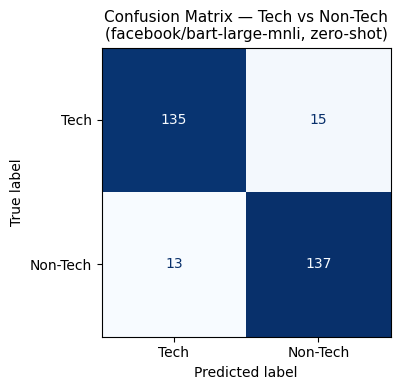

In [8]:
cm = confusion_matrix(y_true, y_pred, labels=['tech', 'non-tech'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Tech', 'Non-Tech'])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Tech vs Non-Tech\n(facebook/bart-large-mnli, zero-shot)', fontsize=11)
plt.tight_layout()
plt.savefig('../report/confusion_matrix.png', dpi=150)
plt.show()

## 6. Confidence Distribution

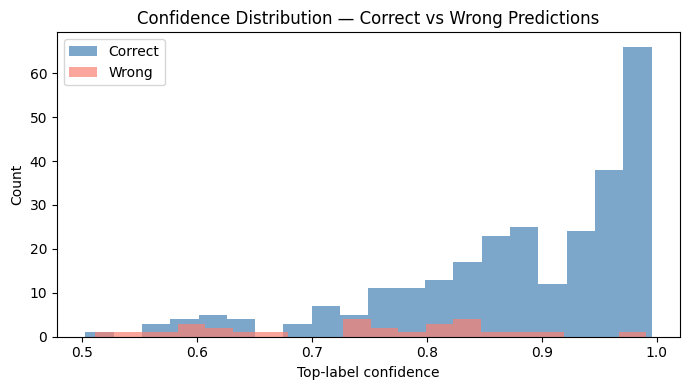

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))

correct = eval_df[eval_df['true_label'] == eval_df['pred_label']]['confidence']
wrong   = eval_df[eval_df['true_label'] != eval_df['pred_label']]['confidence']

ax.hist(correct, bins=20, alpha=0.7, label='Correct', color='steelblue')
ax.hist(wrong,   bins=20, alpha=0.7, label='Wrong',   color='salmon')
ax.set_xlabel('Top-label confidence')
ax.set_ylabel('Count')
ax.set_title('Confidence Distribution — Correct vs Wrong Predictions')
ax.legend()
plt.tight_layout()
plt.savefig('../report/confidence_dist.png', dpi=150)
plt.show()

## 7. Subcategory Distribution

In [10]:
# Descriptive hypothesis labels — same as classifier.py in the app
HYPOTHESIS_LABELS = [
    'artificial intelligence or machine learning',
    'technology startups, funding, or business strategy',
    'consumer electronics, gadgets, chips, or hardware devices',
    'software applications, platforms, or developer tools',
    'general technology news',
]
DISPLAY_NAMES = [
    'AI & Machine Learning',
    'Startups & Business',
    'Gadgets & Hardware',
    'Software & Apps',
    'General Tech',
]
HYP_TO_DISPLAY = dict(zip(HYPOTHESIS_LABELS, DISPLAY_NAMES))

tech_headlines_df = eval_df[eval_df['true_label'] == 'tech'].copy()
tech_texts = tech_headlines_df['headline_text'].tolist()

sub_results = clf(tech_texts, candidate_labels=HYPOTHESIS_LABELS, batch_size=16, multi_label=False)
tech_headlines_df['model_label'] = [HYP_TO_DISPLAY[r['labels'][0]] for r in sub_results]

print('Model prediction distribution:')
print(tech_headlines_df['model_label'].value_counts())

Model prediction distribution:
model_label
Gadgets & Hardware       67
Software & Apps          39
General Tech             37
Startups & Business       5
AI & Machine Learning     2
Name: count, dtype: int64


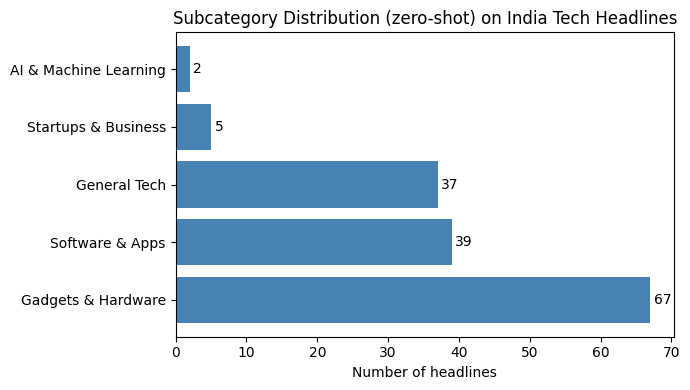

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = tech_headlines_df['model_label'].value_counts()
ax.barh(counts.index, counts.values, color='steelblue')
ax.set_xlabel('Number of headlines')
ax.set_title('Subcategory Distribution (zero-shot) on India Tech Headlines')
for i, v in enumerate(counts.values):
    ax.text(v + 0.5, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../report/subcategory_dist.png', dpi=150)
plt.show()

## 9. Ablation — Hypothesis Label Phrasing

MNLI performance is sensitive to how candidate labels are phrased.  
We compare three label sets for the binary task.

In [15]:
label_sets = {
    'Descriptive':  ['technology news', 'non-technology news'],
    'Short':        ['tech', 'not tech'],
    'Hypothesis':   ['This headline is about technology.', 'This headline is not about technology.'],
}

ablation_rows = []
for name, labels in label_sets.items():
    preds_raw = clf(texts, candidate_labels=labels, batch_size=16, multi_label=False)
    preds = ['tech' if r['labels'][0] == labels[0] else 'non-tech' for r in preds_raw]
    acc_abl = accuracy_score(y_true, preds)
    _, _, f1_abl, _ = precision_recall_fscore_support(y_true, preds, average='binary', pos_label='tech')
    ablation_rows.append({'Label set': name, 'Accuracy': round(acc_abl, 3), 'F1': round(f1_abl, 3)})
    print(f'{name:15s} → Accuracy: {acc_abl:.3f}  F1: {f1_abl:.3f}')

pd.DataFrame(ablation_rows)

Descriptive     → Accuracy: 0.907  F1: 0.906
Short           → Accuracy: 0.647  F1: 0.727
Hypothesis      → Accuracy: 0.637  F1: 0.725


,Label set,Accuracy,F1
0,Descriptive,0.907,0.906
1,Short,0.647,0.727
2,Hypothesis,0.637,0.725


## Summary

| Metric | Value |
| --- | --- |
| Binary Accuracy | _fill after run_ |
| Binary F1 | _fill after run_ |
| Best label phrasing | _fill after ablation_ |
| Most confused subcategory pair | _fill after subcategory CM_ |

Plots saved to `report/` for inclusion in the PDF report:
- `confusion_matrix.png`
- `confidence_dist.png`
- `subcategory_dist.png`
- `subcategory_confusion_matrix.png`